# QFTI_WithSignRecovery.ipynb


### Imports

In [1]:
# Starting timer
import time
time_0t = time.time()

# General Stuffs
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.linalg.interpolative import estimate_spectral_norm
import pandas as pd
import os

# Qiskit Stuffs
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import RXGate, UnitaryGate, HGate
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit.primitives import StatevectorSampler as Sampler

# Setting Figure Font
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Computer modern']})
rc('text', usetex=True)

Path = '/Users/jordancioni/Desktop/Files/School/GradSchool/Research/Programming/Qftd_Qfti/QftiCircuits/PartialSum_MPO'

### Execution Parameters

In [2]:
# Number of shots
num_shots = 10**6

# Number of qubits
n = 6

# Number of samples
Samples = 2**n

### Input Function

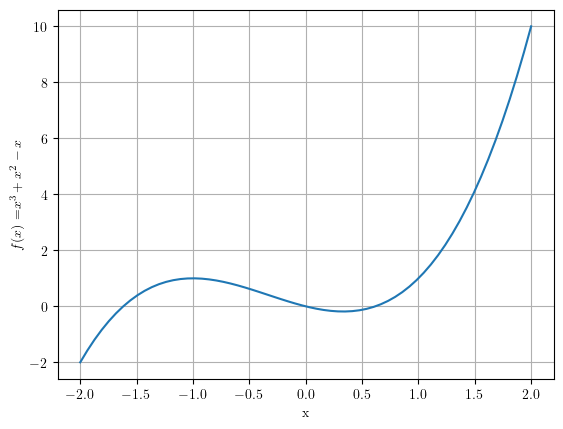

In [3]:
# # f(x) = x
# x = np.linspace(-1, 1, Samples)
# fx = 1*x
# Fx = (x**2)/2 - (np.min(x)**2)/2
# str_fx = r'$x$'
# str_save = 'QFTI_x'


# # f(x) = cos(2pix)
# x = np.linspace(-1, 1, Samples)
# fx = np.cos(2*np.pi*x)
# Fx = np.sin(2*np.pi*x)/(2*np.pi) - np.sin(2*np.pi*np.min(x))/(2*np.pi)
# str_fx = r'$\cos(2\pi x)$'
# str_save = 'QFTI_cos2PiX'


# # f(x) = 1/x
# x = np.linspace(-1, 1, Samples)
# fx = 1/x
# Fx = np.log(np.abs(x)) - np.log(np.abs(np.min(x)))
# # Function Strings for final analysis
# str_fx = '1/x' # Original Function
# str_save = 'QFTI_1overX'


# f(x) = x^3 +x^2 - x
x=np.linspace(-2, 2, Samples)
fx = x**3 + x**2 - x
Fx = (x**4)/4 + (x**3)/3 - (x**2)/2
Fx = Fx-Fx[0]
# Function strings for final analysis
str_fx = r'$x^3 + x^2 - x$'
str_save = 'QFTI_Signs_Poly'


# # f(x) = cos(pi x) + sin(3pi x)
# x = np.linspace(-2, 2, Samples)
# fx = np.cos(np.pi*x/2) + np.sin(3*np.pi*x/2)
# Fx = np.sin(np.pi*x/2)*2/np.pi - np.cos(3*np.pi*x/2)*2/(3*np.pi)
# Fx = Fx - Fx[0]
# # Function strings for final analysis
# str_fx = r'$\cos(\pi x / 2) + \sin(3\pi x / 2)$'
# str_save = 'QFTI_Signs_MultipleTrig'


# Plotting Function
plt.plot(x,fx);
plt.xlabel('x');
plt.ylabel(f'{r'$f(x) = $'}{str_fx}');
plt.grid()
# plt.title('Function to Integrate');

### Normalizing Input Vector and Finding Scaling Info

In [4]:
# Getting Norm
Norm = np.sqrt(np.sum(fx**2))

# Getting deltaX
deltaX = x[1] - x[0]

# Getting Resolution
Res = (1/(10**7))*((Norm/deltaX)**2)



***
# Creating Circuit

### Constructing Registers

In [5]:
# Constructing Registers
k = QuantumRegister(n, 'j')
a = QuantumRegister(3, 'a')
b = QuantumRegister(1, 'b')

### Constructing QFT Circuit

In [6]:
# Initializing QFT circuit
qft_circ = QuantumCircuit(k)

# Iterating through target bits
for target in range(n-1, -1, -1):
    
    # Apply hadamard gate to target
    qft_circ.h(k[target])
    
    # Iterate through controll qubits to 0
    for control in range(target-1,-1,-1):
        
        # Calculate r for controlled rotation
        r = target-control+1
        
        # Apply controlled phase (or rotation)
        qft_circ.cp(-2*np.pi/2**r, k[control], k[target])

# Swap qubits
for qubit in range(n//2):
    qft_circ.swap(qubit, n-qubit-1)

# Drawing QFT Circuit
# fig, axs = plt.subplots(ncols=1, nrows=1, layout="constrained", figsize=(6, 3))
# qft_circ.draw('mpl', ax = axs)

### Converting QFT Circuit to Gates

In [7]:
# Converting QFT Circuit to a Gate
qft = qft_circ.to_gate()
qft.label = "QFT"


# Creating Controlled IQFT Gate
iqft = qft.inverse()
iqft.label = "IQFT"

# Setting IQFT control state
c_iqft0 = iqft.control(1, ctrl_state = '0')

### Constructing Wavenumber Rotation Circuit

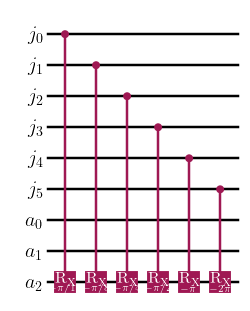

In [8]:
# Initializing WaveNumber Rotation circuit
WaveNumber_circ = QuantumCircuit(k, a)

# Performing controlled rotations to get that elusive sin term(s)
for target in range(n):
    r = n-target
    r_inv = target+1
    # Appending rotation gates
    WaveNumber_circ.crx(-2*(2*np.pi/2**r), k[target], a[2])
    
# Converting Wavenumber Rotation Circuit to Gate
WaveNumberRotation = WaveNumber_circ.to_gate()
WaveNumberRotation.label = "Wavenumber Rotations"

# Drawing Wavenumber Rotation Circuit
fig, axs = plt.subplots(ncols=1, nrows=1, layout="constrained", figsize=(6, 3))
WaveNumber_circ.draw('mpl', ax = axs)

### Custom partial summation matrix

In [ ]:
# Creating Matrix
A = np.ones((Samples, Samples))
A = np.tril(A)

# Making A hermitian
A = np.vstack((np.hstack( (np.zeros((Samples, Samples)), np.conj(A.transpose())) ),
                         np.hstack( (A, np.zeros((Samples,Samples))) )
                         ))
N = estimate_spectral_norm(A)

# Getting eigenvector matrices
[evals, P] = scipy.linalg.eigh(A)
P_inv = np.conj(P.transpose())

# Getting Diagonal matrix
D = np.matmul(P_inv, np.matmul(A, P))

# Getting Identity matrix
I = np.eye(2**(n+1))

# Getting B matrix
B = np.matmul(scipy.linalg.sqrtm(I-(np.matmul(D, D)/(N**2))), P_inv)

# Concatenating 
W = np.vstack((A/N, B))

# Performing QR Decomposition
U, R = scipy.linalg.qr(W)

# Converting Unitary Parital Sum MPO to a Unitary Gate
PsMPO = UnitaryGate(-U, label=r"$U_H$")
PsMPO = PsMPO.control(1, ctrl_state = '0')


### Creating QFTI Circuit and Gate

In [ ]:
# Initializing circuit
qfti_circ = QuantumCircuit(k, a)

# Appending all gates
# qfti_circ.barrier(label=f"{r'$|\Psi_0\rangle$'}")
qfti_circ.append(qft, k[:])
# qfti_circ.barrier(label=f"{r'$|\Phi_0\rangle$'}")
qfti_circ.append(WaveNumberRotation, k[:]+a[:])
# qfti_circ.barrier(label=f"{r'$|\Phi_1\rangle$'}")
qfti_circ.append(c_iqft0, [a[2]]+k[:])
# qfti_circ.barrier(label=f"{r'$|\Psi_1\rangle$'}")
qfti_circ.append(PsMPO, [a[2]]+k[:]+[a[0]]+[a[1]])
# qfti_circ.barrier(label=f"{r'$|\Psi_2\rangle$'}")

# Converting circuit to a gate
QFTI = qfti_circ.to_gate()
QFTI.label = "QFTI"
cQFTI = QFTI.control()

# Creating Subplots
fig, axs = plt.subplots(ncols=1, nrows=1, layout="constrained", figsize=(6, 3))

# Drawing QFTD Circuit
qfti_circ.decompose(gates_to_decompose = 'Wavenumber Rotations').draw('mpl', ax = axs)
# fig.savefig(f"ThreeQubit_QftiCircuit.png", format='png', dpi=1200)

### Building Final Circuit

In [ ]:
# Creating Quantum Circuit
qc = QuantumCircuit(k, a)
qc_sign = QuantumCircuit(k, a, b)

# Encoding input funtion to k-register
qc.initialize(fx/Norm, k);
qc_sign.initialize(fx/Norm, k);

# Applying H to Sign Recovery b ancilla
qc_sign.h(b[:])

# Apply QFTD Gate
qc.append(QFTI, k[:]+a[:])
qc_sign.append(cQFTI, b[:]+k[:]+a[:])

mch = HGate().control(1, ctrl_state = '0')

# Testing Hadamard idea
qc_sign.cx(a[0],b[:])
qc_sign.append(mch, b[:]+[a[0]])

# Measure all qubits
qc.measure_all()
qc_sign.measure_all()

# Saving Circuit Figure
fig, axs = plt.subplots(ncols=1, nrows=1, layout="constrained", figsize=(6, 6))
qc_sign.draw('mpl', fold=-1, ax = axs)
# fig.savefig(f"SignRecoveryCirc_QFTI.png", format='png', dpi=1200)

***
# Running Final Circuit

### Running Integral

In [ ]:
# ### Using Aer
# # Assigning a (simulator) "backend"
# backend = AerSimulator(method='statevector', max_parallel_threads=14)
# # Starting Execution Timer
# time_0e = time.time()
# # "Transpiling" the circuit
# pm = generate_preset_pass_manager(3, backend)
# qc_transpiled = pm.run(qc)
# # Executing
# final_job = backend.run(qc_transpiled, shots = num_shots)
# # Getting Counts (Aer)
# final_counts = final_job.result().get_counts()
# # Getting Execution Time
# ExecutionTimeString = f"Execution Time:\t{time.time()-time_0e}"
# print(ExecutionTimeString)


### Using Sampler
# Assigning a (simulator) "backend"
backend = Sampler()
# Starting Execution Timer
time_0e = time.time()
# Executing
final_job = backend.run([qc], shots = num_shots) 
# Getting Counts (Sampler)
final_counts = final_job.result()[0].data.meas.get_counts()
# Getting Execution Time
ExecutionTimeString = f"Execution Time:\t{time.time()-time_0e}"
print(ExecutionTimeString)


# Plotting Results
HistogramTitle = f"{str_fx} QFTI, Qubits={n}, Shots=10e{np.log10(num_shots)}"
plot_histogram(final_counts, figsize=(6, 3), bar_labels=False, title=HistogramTitle)

### Running Sign Estimation

In [ ]:
# ### Using Aer
# # Assigning a (simulator) "backend"
# backend = AerSimulator(method='statevector', max_parallel_threads=14)
# # Starting Execution Timer
# time_0e = time.time()
# # "Transpiling" the circuit
# pm = generate_preset_pass_manager(3, backend)
# qc_transpiled = pm.run(qc_sign)
# # Executing
# final_job_sign = backend.run(qc_transpiled, shots = num_shots)
# # Getting Counts (Aer)
# final_counts_sign = final_job_sign.result().get_counts()
# # Getting Execution Time
# ExecutionTimeString = f"Execution Time:\t{time.time()-time_0e}"
# print(ExecutionTimeString)

### Using Sampler
# Assigning a (simulator) "backend"
backend = Sampler()
# Starting Execution Timer
time_0e = time.time()
# Executing
final_job_sign = backend.run([qc_sign], shots = num_shots) 
# Getting Counts (Sampler)
final_counts_sign = final_job_sign.result()[0].data.meas.get_counts()
# Getting Execution Time
ExecutionTimeString = f"Execution Time:\t{time.time()-time_0e}"
print(ExecutionTimeString)


# Plotting Results
HistogramTitle = f"{str_fx} QFTI Sign Recovery, Qubits={n}, Shots=10e{np.log10(num_shots)}"
plot_histogram(final_counts_sign, figsize=(6, 3), bar_labels=False, title=HistogramTitle)

***
# Evaluating Results

### Discarding Measurements with Ancilla Outside 001 State

In [ ]:
# Finding unsuccesfull shots
delItem = []
for key, val in final_counts.items():
    # Check a_2 qubit (should be 0)
    if key[0] == '1': 
       delItem.append(key)
    # Check a_1 qubit (should be 0)
    elif key[1] == '1':
        delItem.append(key)
    # Check a_0 qubit (should be 1)
    elif key[2] == '0':
        delItem.append(key)

    
for item in delItem:
    final_counts.pop(item)

# # Plotting only succesfull shots
HistogramTitle = f"Successfull Shots"
plot_histogram(final_counts, figsize=(14, 7), bar_labels=False, title=HistogramTitle)

### Processing Results into Usefull Form

In [ ]:
Yout = np.zeros(2**n)
for thing in final_counts.keys():
    ind = int(thing[3:],2)# we have the bitstring 'abcFFF' and only want last third (~abc~)FFF
    Yout[ind] = final_counts[thing]


### Obtaining Sign Information

In [ ]:
signs = np.ones(2**n)
Yout_Signs_Comp = np.zeros((2**n,2))
for bitstring in final_counts_sign.keys():
    # Negelect any states where b qubit is 1
    if bitstring[:3] == '000': 
        # Converting bitstring to index
        ind = int(bitstring[4:],2)
        state = 0
        if bitstring[3] == '1':
            state = 1
        Yout_Signs_Comp[ind,state] = final_counts_sign[bitstring]


for ind in range(len(fx)):
    comp = Yout_Signs_Comp[ind,0] - Yout_Signs_Comp[ind,1]
    if fx[ind]<0:
        if comp > 0:
            signs[ind] = -1
        else:
            signs[ind] = 1
    elif fx[ind] > 0:
        if comp > 0:
            signs[ind] = 1
        else:
            signs[ind] = -1



### Scaling Yout

In [ ]:
# Recovering amplitude
Yout_Squared = np.divide(Yout, num_shots) * ((N*Norm*deltaX)**2)
Yout_Signs = np.sqrt(np.divide(Yout, num_shots) * ((N*Norm*deltaX)**2))*signs

### Evaluating R-Squared

In [ ]:
#r2 = 1- sum[(Yactual - Yfit)^2]/sum[(Yactual-mean(Yactual))^2]

# Finding mean
meanFx_Squared = np.average(Fx**2)
meanFx_Signs = np.average(Fx)

# Finding residuals
res_Squared = Fx**2 - Yout_Squared
res_Signs = Fx - Yout_Signs

# Finding total variance
var_Squared = Fx**2 - meanFx_Squared
var_Signs = Fx - meanFx_Signs

# Finding coefficient of determination
R2_Squared = 1 - np.divide(sum(res_Squared**2), sum(var_Squared**2))
R2_Signs = 1 - np.divide(sum(res_Signs**2), sum(var_Signs**2))

# Printing Result
print(f"R^2 = {R2_Squared} (squared)")
print(f"R^2 = {R2_Signs} (signed)")

***
# Outputs

### Plotting Squared Results

In [ ]:
# Y Limits
Yrange = np.max(Fx**2)-np.min(Fx**2)
ylim0 = -Yrange*0.10 + np.min(Fx**2)
ylim1 = Yrange*0.10 + np.max(Fx**2)

# Creating Figure
fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(6, 3))

# Plotting Analytical Derivative
TruIntegral = axs.plot(x, Fx**2, color='black', label='Analytic')
# Plotting Quantum Results
QftIntegral = axs.scatter(x, Yout_Squared, alpha=0.75, label='QFTI', marker = 'x')
# Dummy plot to include r-squared in legend
R2Text = axs.scatter([],[], marker = 'none', label=f'$R^2 = {np.round(R2_Squared, 3)}$')

# Formatting plot
axs.grid()
axs.set_xlabel('x', fontsize = 11)
axs.set_ylabel(r'$[\int f(x) d x]^2$', fontsize = 11)
axs.set_ylim(ylim0, ylim1)
axs.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left', ncols=3, mode="expand", borderaxespad=0., fontsize=11);

# # Saving plot
# fig.savefig(f"Qfti_SquaredOnly_{str_save}_Nq{n}Ns10e{np.log10(num_shots)}.png", format='png', dpi=1200, bbox_inches='tight')

### Results with Sign Recovery

In [ ]:
# Y Limits
Yrange = np.max(Yout_Signs)-np.min(Yout_Signs)
ylim1 = Yrange*0.10 + np.max(Yout_Signs)
ylim0 = -Yrange*0.10 + np.min(Yout_Signs)

# Creating Figure
fig, axs = plt.subplots(ncols=1, nrows=1, figsize=(6, 3))

# Plotting Analytical Integral
TruIntegral = axs.plot(x, Fx, color='black', label='Analytic')
# Plotting Quantum Results
QftIntegral = axs.scatter(x, Yout_Signs, alpha=0.75, label='QFTI', marker = 'x')
# Dummy plot to include r-squared in legend
R2Text = axs.scatter([],[], marker = 'none', label=f'$R^2 = {np.round(R2_Signs, 3)}$')

# Formatting plot
axs.grid()
axs.set_xlabel('x', fontsize = 11)
axs.set_ylabel(r'$\int f(x) d x$', fontsize = 11)
axs.set_ylim(ylim0, ylim1)
axs.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left', ncols=3, mode="expand", borderaxespad=0., fontsize=11);

# # Saving plot
# fig.savefig(f"Qfti_SignRecovery_{str_save}_Nq{n}Ns10e{np.log10(num_shots)}.png", format='png', dpi=1200, bbox_inches='tight')


### Execution Time

In [ ]:
# Getting Total Time
TotalTimeString = f"Total Time:\t{time.time()-time_0t}"

# Printing to window
print(TotalTimeString)

### Saving Results

In [ ]:
# # Saving Data
# np.savez(f"{str_save}_Nq{n}_Ns10e{round(np.log10(num_shots))}_Data.npz", 
#          R2_Squared = R2_Squared, Yout_Squared = Yout_Squared,
#          R2_Signs = R2_Signs, Yout_Signs = Yout_Signs,
#          Norm = Norm, Xout = x, Fx_th = Fx, str_fx = str_fx, deltaX=deltaX)
# Data = np.load(f"{str_save}_Nq{n}_Ns10e{round(np.log10(num_shots))}_Data.npz")